# <font color="#418FDE" size="6.5" uppercase>**NLP, Transformers, and Multi-Modal Models**</font>

>Last update: 20260421.
    
By the end of this Lecture, you will be able to:
- Preprocess simple text data and implement introductory TensorFlow natural language processing workflows. 
- Explain the basic idea of attention and transformers and build small TensorFlow examples that use these mechanisms. 
- Describe and implement a simple multi-modal TensorFlow model that combines image and text information. 


## **1. Introductory NLP Workflows**

### **1.1. Text Tokenization Basics**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_11/Lecture_B/image_01_01.jpg?v=1776824261" width="250">



>* Tokenization splits text into processable units.
>* Token choices shape meaning and NLP tasks.

>* Clean text to reduce meaningless variation.
>* Token vocabularies map text into model inputs.

>* Tokenization choices affect model accuracy and robustness.
>* Subwords and sequence length improve text handling.



TensorFlow version: 2.21.0
Number of sentences: 8
Vocabulary size: 41
First 10 vocabulary items: ['', '[UNK]', np.str_('wall'), np.str_('needs'), np.str_('week'), np.str_('water'), np.str_('tunnel'), np.str_('surface'), np.str_('steel'), np.str_('shows')]
Raw sentence: Concrete crack near pier 2.
Cleaned tokens: ['concrete', 'crack', 'near', 'pier', '2']
Integer ids: [34, 32, 19, 15, 40, 0]


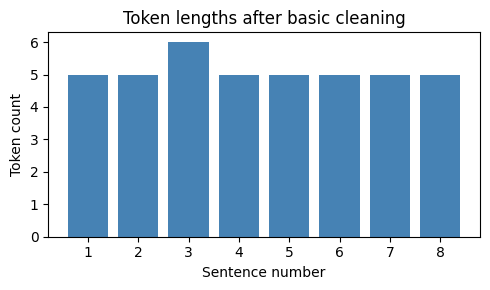

In [43]:
#@title Python Code - Text Tokenization Basics

# Small text data shows tokenization basics.
# TensorFlow converts words into integer tokens.
# Civil engineering sentences keep examples familiar.

import os, warnings, random
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')
import tensorflow as tf

tf.get_logger().setLevel('ERROR')

random.seed(7)
np.random.seed(7)
tf.random.set_seed(7)

# Create a tiny engineering text dataset.
texts = [
    'Concrete crack near pier 2.',

    'Bridge deck needs minor repair.',
    'Water leak detected in tunnel wall.',
    'Steel beam shows surface corrosion.',

    'Road shoulder has loose gravel.',
    'Retaining wall needs drainage check.',
    'Safety barrier damaged after impact.',

    'Pavement patch performed last week.']

# Store text in a small table.
df = pd.DataFrame({'report': texts})

# Build a simple text vectorizer.
vectorizer = tf.keras.layers.TextVectorization(
    standardize='lower_and_strip_punctuation',

    split='whitespace',
    output_mode='int',
    output_sequence_length=6,

    max_tokens=50)

# Adapt the layer to our text.
text_ds = tf.data.Dataset.from_tensor_slices(df['report'].values)
vectorizer.adapt(text_ds.batch(4))

# Get the learned vocabulary list.
vocab = vectorizer.get_vocabulary()

# Compare raw text and token ids.
sample_text = df['report'].iloc[0]
encoded = vectorizer(tf.constant([sample_text])).numpy()[0]

cleaned_words = []
for token in sample_text.lower().replace('.', '').split():
    cleaned_words.append(token)

# Count token lengths after cleaning.
lengths = []
for sentence in df['report']:

    cleaned = sentence.lower().replace('.', '')
    lengths.append(len(cleaned.split()))

# Print a short summary.
print('TensorFlow version:', tf.__version__)
print('Number of sentences:', len(df))

print('Vocabulary size:', len(vocab))
print('First 10 vocabulary items:', vocab[:10])
print('Raw sentence:', sample_text)

print('Cleaned tokens:', cleaned_words)
print('Integer ids:', encoded.tolist())

# Plot token lengths for each sentence.
plt.figure(figsize=(5, 3))
plt.bar(range(1, len(lengths) + 1), lengths, color='steelblue')

plt.xlabel('Sentence number')
plt.ylabel('Token count')
plt.title('Token lengths after basic cleaning')

plt.xticks(range(1, len(lengths) + 1))
plt.tight_layout()
plt.show()

### **1.2. Text Embeddings Classification**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_11/Lecture_B/image_01_02.jpg?v=1776824301" width="250">



>* Embeddings map similar words near together.
>* TensorFlow classifies tokenized text using learned vectors.

>* Models learn classes from repeated labeled examples.
>* Embeddings improve text summaries in TensorFlow pipelines.

>* Useful for focused tasks, with limits.
>* Needs quality data, preprocessing, and evaluation.



TensorFlow version: 2.21.0
Validation loss: 0.693
Validation accuracy: 0.25
Confusion matrix: [[2, 2], [4, 0]]
                                text  true  pred  prob
   joint sealant missing and leaking     1     0   0.5
barrier alignment appears acceptable     0     1   0.5
  fracture visible in retaining wall     1     0   0.5
 road markings are clear and visible     0     0   0.5


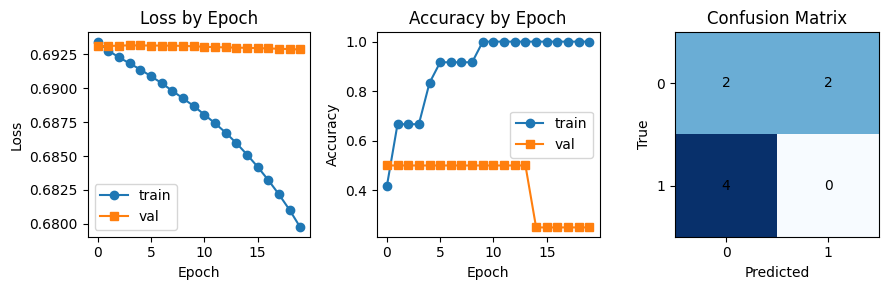

In [44]:
#@title Python Code - Text Embeddings Classification

# Small text embeddings classification example.
# TensorFlow workflow for civil engineering text.
# Beginner friendly and Colab ready.

# Install helper library if needed.
# pip install scikit-learn

import os, warnings, random
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')
import tensorflow as tf

from sklearn.metrics import confusion_matrix

tf.get_logger().setLevel('ERROR')
random.seed(7)
np.random.seed(7)

tf.random.set_seed(7)

# Show TensorFlow version briefly.
print('TensorFlow version:', tf.__version__)

# Create a tiny labeled dataset.
texts = [
    'crack found near bridge joint',

    'spalling observed on concrete beam',
    'water leakage under deck slab',
    'rust around steel connection plate',

    'pothole growing near lane edge',
    'loose guardrail needs urgent repair',
    'surface staining only no damage',

    'routine inspection found normal pavement',
    'bridge paint condition looks good',
    'sidewalk is clean and accessible',

    'drainage channel working as expected',
    'minor dust present but safe area',
    'fracture visible in retaining wall',

    'settlement noticed beside foundation corner',
    'joint sealant missing and leaking',
    'inspection notes indicate severe corrosion',

    'lighting system operating normally',
    'barrier alignment appears acceptable',
    'road markings are clear and visible',

    'no structural concern in this report']

labels = [
    1, 1, 1, 1, 1, 1,
    0, 0, 0, 0, 0, 0,

    1, 1, 1, 1,
    0, 0, 0, 0]

# Build a small dataframe.
df = pd.DataFrame({'text': texts, 'label': labels})

# Split into train and validation sets.
train_df = pd.concat([
    df[df['label'] == 1].iloc[:6],

    df[df['label'] == 0].iloc[:6]
], ignore_index=True)

val_df = pd.concat([
    df[df['label'] == 1].iloc[6:],
    df[df['label'] == 0].iloc[6:]

], ignore_index=True)

# Shuffle both splits simply.
train_df = train_df.sample(frac=1, random_state=7).reset_index(drop=True)
val_df = val_df.sample(frac=1, random_state=7).reset_index(drop=True)

# Check dataset sizes safely.
if len(train_df) < 4 or len(val_df) < 2:
    raise ValueError('Dataset split is too small.')

# Prepare TensorFlow datasets.
train_texts = train_df['text'].astype(str).tolist()
train_labels = train_df['label'].values.astype('float32')

val_texts = val_df['text'].astype(str).tolist()
val_labels = val_df['label'].values.astype('float32')

# Convert text to TensorFlow string tensors.
train_texts_tf = tf.convert_to_tensor(train_texts, dtype=tf.string)
val_texts_tf = tf.convert_to_tensor(val_texts, dtype=tf.string)

train_ds = tf.data.Dataset.from_tensor_slices((train_texts_tf, train_labels))
train_ds = train_ds.batch(4)

val_ds = tf.data.Dataset.from_tensor_slices((val_texts_tf, val_labels))
val_ds = val_ds.batch(4)

# Create the text vectorizer.
vectorizer = tf.keras.layers.TextVectorization(
    max_tokens=100,

    output_mode='int',
    output_sequence_length=8)

# Adapt vocabulary on training text.
vectorizer.adapt(train_texts_tf)

# Build a lightweight classifier.
model = tf.keras.Sequential([
    tf.keras.Input(shape=(), dtype=tf.string),

    vectorizer,
    tf.keras.layers.Embedding(input_dim=100, output_dim=8),
    tf.keras.layers.GlobalAveragePooling1D(),

    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')])

# Compile the model simply.
model.compile(
    optimizer='adam',

    loss='binary_crossentropy',
    metrics=['accuracy'])

# Train quietly for a few epochs.
history = model.fit(
    train_ds,

    validation_data=val_ds,
    epochs=20,
    verbose=0)

# Evaluate on validation data.
val_probs = model.predict(val_texts_tf, verbose=0).flatten()
val_preds = (val_probs >= 0.5).astype(int)

cm = confusion_matrix(val_labels, val_preds)

# Build a short prediction table.
summary_df = pd.DataFrame({
    'text': val_texts,

    'true': val_labels.astype(int),
    'pred': val_preds,
    'prob': np.round(val_probs, 2)})

# Print compact learning summary.
final_loss = history.history['val_loss'][-1]
final_acc = history.history['val_accuracy'][-1]

print('Validation loss:', round(float(final_loss), 3))
print('Validation accuracy:', round(float(final_acc), 3))
print('Confusion matrix:', cm.tolist())

print(summary_df.head(4).to_string(index=False))

# Create one figure with three panels.
fig, axes = plt.subplots(1, 3, figsize=(9, 3))

# Plot training and validation loss.
axes[0].plot(history.history['loss'], marker='o', label='train')
axes[0].plot(history.history['val_loss'], marker='s', label='val')

axes[0].set_title('Loss by Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')

axes[0].legend()

# Plot training and validation accuracy.
axes[1].plot(history.history['accuracy'], marker='o', label='train')
axes[1].plot(history.history['val_accuracy'], marker='s', label='val')

axes[1].set_title('Accuracy by Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')

axes[1].legend()

# Plot a simple confusion matrix.
image = axes[2].imshow(cm, cmap='Blues')
axes[2].set_title('Confusion Matrix')

axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('True')
axes[2].set_xticks([0, 1])

axes[2].set_yticks([0, 1])

# Add matrix values clearly.
axes[2].text(0, 0, str(cm[0, 0]), ha='center', va='center')
axes[2].text(1, 0, str(cm[0, 1]), ha='center', va='center')

axes[2].text(0, 1, str(cm[1, 0]), ha='center', va='center')
axes[2].text(1, 1, str(cm[1, 1]), ha='center', va='center')

# Finish and show the figure.
plt.tight_layout()
plt.show()

### **1.3. Next Token Prediction**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_11/Lecture_B/image_01_03.jpg?v=1776824348" width="250">



>* Models predict the next token from context.
>* TensorFlow preprocesses text into training sequences.

>* Build sequences from small tokenized text sets.
>* Train embeddings to predict contextually likely words.

>* Next token prediction reveals model strengths, limits.
>* Evaluation and preprocessing choices strongly shape performance.



TensorFlow: 2.21.0
Device: CPU
Vocabulary size: 39
Example sentence: concrete strength increased after curing
Token ids: [5, 6, 4, 38, 34]
Training pairs: 48
Input: concrete -> strength
Input: concrete strength -> increased
Input: concrete strength increased -> after
Prompt: concrete strength -> increased
Prompt: bridge inspection found -> surface
Prompt: road surface crack -> width
Prompt: heavy rainfall -> caused


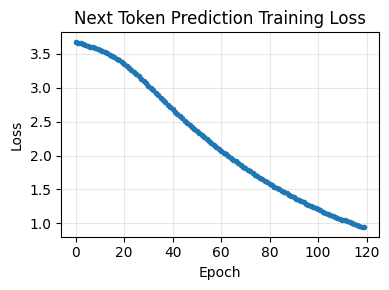

In [45]:
#@title Python Code - Next Token Prediction

# Small TensorFlow example for next token prediction.
# Civil engineering text sequences become training pairs.
# Students inspect tokens, loss, and predictions.

# Import quiet settings and core libraries.
import os, warnings, random
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

warnings.filterwarnings('ignore')
import numpy as np

# Import plotting and TensorFlow tools.
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

# Reduce TensorFlow warning messages.
tf.get_logger().setLevel('ERROR')
np.random.seed(7)

random.seed(7)
tf.random.set_seed(7)

# Report version and device choice.
gpu_found = len(tf.config.list_physical_devices('GPU')) > 0
print('TensorFlow:', tf.__version__)

print('Device:', 'GPU' if gpu_found else 'CPU')

# Create a tiny civil engineering corpus.
texts = [
    'concrete strength increased after curing',

    'concrete strength was measured today',
    'bridge inspection found surface cracks',
    'bridge inspection found loose bolts',

    'road surface crack depth increased',
    'road surface crack width increased',
    'heavy rainfall delayed concrete pouring',

    'heavy rainfall caused site flooding',
    'steel beam load test passed',
    'steel beam load test failed',

    'foundation soil test showed settlement',
    'foundation soil test showed moisture',]

# Build a text vectorization layer.
vectorizer = layers.TextVectorization(
    standardize='lower_and_strip_punctuation',

    split='whitespace',
    output_mode='int')
vectorizer.adapt(tf.data.Dataset.from_tensor_slices(texts).batch(4))

# Read the learned vocabulary.
vocab = vectorizer.get_vocabulary()
word_to_id = {}

for i in range(len(vocab)):
    word_to_id[vocab[i]] = i

# Convert each sentence into token ids.
all_sequences = []
for text in texts:

    ids = vectorizer(tf.constant([text])).numpy()[0]
    ids = ids[ids != 0]
    all_sequences.append(ids)

# Create input and target examples.
x_list = []
y_list = []

for ids in all_sequences:
    for end_pos in range(2, len(ids) + 1):
        x_list.append(ids[:end_pos - 1])

        y_list.append(ids[end_pos - 1])

# Pad inputs to equal length.
max_len = 0
for seq in x_list:

    if len(seq) > max_len:
        max_len = len(seq)

# Prepare arrays for training.
x_train = keras.preprocessing.sequence.pad_sequences(
    x_list, maxlen=max_len, padding='pre')

y_train = np.array(y_list, dtype='int32')
vocab_size = len(vocab)

# Show a few tokenized examples.
print('Vocabulary size:', vocab_size)
print('Example sentence:', texts[0])

print('Token ids:', all_sequences[0].tolist())
print('Training pairs:', x_train.shape[0])

# Decode a few training pairs.
for i in range(3):
    input_words = []

    for token_id in x_list[i]:
        input_words.append(vocab[int(token_id)])
    target_word = vocab[int(y_list[i])]

    print('Input:', ' '.join(input_words), '->', target_word)

# Build a very small prediction model.
model = keras.Sequential([
    layers.Input(shape=(max_len,)),

    layers.Embedding(vocab_size, 16),
    layers.SimpleRNN(24),
    layers.Dense(vocab_size, activation='softmax')])

# Compile the model for training.
model.compile(
    optimizer='adam',

    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])

# Train silently for a few epochs.
history = model.fit(
    x_train, y_train,

    epochs=120,
    verbose=0)

# Predict the next word for prompts.
def predict_next(prompt):
    ids = vectorizer(tf.constant([prompt])).numpy()[0]

    ids = ids[ids != 0]
    padded = keras.preprocessing.sequence.pad_sequences(
        [ids], maxlen=max_len, padding='pre')

    probs = model.predict(padded, verbose=0)[0]
    next_id = int(np.argmax(probs))
    return vocab[next_id]

# Show a few next word predictions.
prompts = [
    'concrete strength',

    'bridge inspection found',
    'road surface crack',
    'heavy rainfall',]

for prompt in prompts:
    print('Prompt:', prompt, '->', predict_next(prompt))

# Plot epoch versus training loss.
plt.figure(figsize=(4, 3))
plt.plot(history.history['loss'], marker='o', markersize=3)

plt.title('Next Token Prediction Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## **2. Attention and Transformers**

### **2.1. Attention Basics**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_11/Lecture_B/image_02_01.jpg?v=1776824385" width="250">



>* Attention focuses on the most relevant words.
>* It helps models use context correctly.

>* Attention focuses on the most informative words.
>* It captures long-range word relationships effectively.

>* Attention powers transformers by linking distant context.
>* It learns relevance for richer meaning.



TensorFlow version: 2.21.0
Example sentence: the contractor delayed the concrete pour
Tokens: [np.str_('the'), np.str_('contractor'), np.str_('delayed'), np.str_('the'), np.str_('concrete'), np.str_('pour')]
Query token: delayed
Strongest link: the
Weights sum to: 1.001


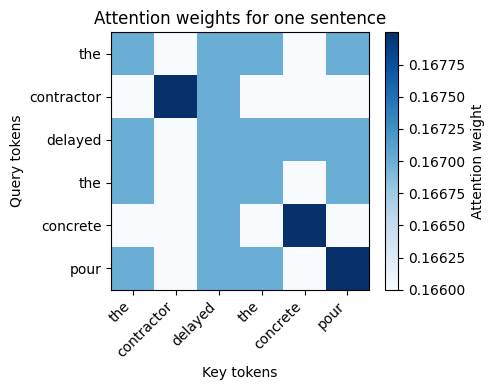

In [46]:
#@title Python Code - Attention Basics

# Attention shows which words matter most.
# This example uses tiny engineering text.
# We visualize simple token attention weights.

# Import quiet libraries for TensorFlow work.
import os, warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

warnings.filterwarnings('ignore')
import numpy as np

# Import plotting and TensorFlow tools.
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.layers import TextVectorization

tf.get_logger().setLevel('ERROR')
np.random.seed(7)
tf.random.set_seed(7)

print('TensorFlow version:', tf.__version__)

# Create a tiny civil engineering dataset.
sentences = [
    'the bridge deck cracked after heavy traffic',

    'the concrete column carried the roof load',
    'heavy rain flooded the access road',
    'the contractor delayed the concrete pour']

# Pick one sentence for attention study.
example_text = 'the contractor delayed the concrete pour'
print('Example sentence:', example_text)

# Build a simple tokenizer layer.
vectorizer = TextVectorization(
    standardize='lower_and_strip_punctuation',

    split='whitespace',
    output_mode='int')
vectorizer.adapt(sentences)

# Convert text into token ids.
example_ids = vectorizer(tf.constant([example_text]))
example_ids = tf.cast(example_ids, tf.int32)

# Recover readable tokens from ids.
vocab = vectorizer.get_vocabulary()
token_ids = example_ids.numpy()[0]

tokens = []
for token_id in token_ids:
    if token_id != 0:

        tokens.append(vocab[int(token_id)])

# Keep only real token positions.
valid_length = len(tokens)
example_ids = example_ids[:, :valid_length]

print('Tokens:', tokens)

# Create a small embedding layer.
embedding = tf.keras.layers.Embedding(
    input_dim=len(vocab),

    output_dim=8)
embedded = embedding(example_ids)

# Use self attention on embeddings.
attention = tf.keras.layers.Attention(
    use_scale=True)

context, scores = attention(
    [embedded, embedded],
    return_attention_scores=True)

# Convert scores into a simple matrix.
score_matrix = scores.numpy()[0]
score_matrix = np.round(score_matrix, 3)

# Explain one query token briefly.
query_index = tokens.index('delayed')
query_weights = score_matrix[query_index]

best_index = int(np.argmax(query_weights))
print('Query token: delayed')
print('Strongest link:', tokens[best_index])

print('Weights sum to:', round(float(np.sum(query_weights)), 3))

# Draw one attention heatmap.
plt.figure(figsize=(5, 4))
plt.imshow(score_matrix, cmap='Blues')

plt.xticks(range(valid_length), tokens, rotation=45, ha='right')
plt.yticks(range(valid_length), tokens)
plt.xlabel('Key tokens')

plt.ylabel('Query tokens')

# Add a clear plot title.
plt.title('Attention weights for one sentence')
plt.colorbar(label='Attention weight')

plt.tight_layout()
plt.show()

### **2.2. Simple Self Attention**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_11/Lecture_B/image_02_02.jpg?v=1776824417" width="250">



>* Tokens weigh other tokens for meaning.
>* Captures long-range context across a sentence.

>* Tokens use queries, keys, and values.
>* Attention weights create context-aware token representations.

>* Self attention links distant words effectively.
>* It underpins transformers and TensorFlow learning.



TensorFlow version: 2.21.0
Queries ask what each word needs.
Keys describe what each word offers.
Values carry the information shared.
bridge crack after rain -> risk score 0.547
bridge safe after repair -> risk score 0.456
column crack after quake -> risk score 0.555


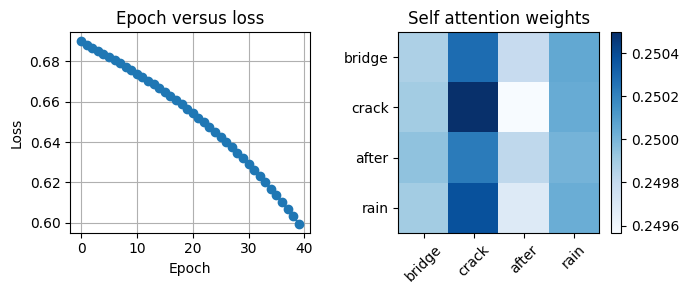

In [47]:
#@title Python Code - Simple Self Attention

# Simple self attention for short engineering text.
# Tiny TensorFlow example with clear attention ideas.
# One plot shows loss and attention weights.

import os, warnings, random
import numpy as np
import matplotlib.pyplot as plt

import pandas as pd

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
warnings.filterwarnings("ignore")
import tensorflow as tf

from tensorflow import keras

tf.get_logger().setLevel("ERROR")
np.random.seed(7)
random.seed(7)

tf.random.set_seed(7)

# Print short framework information.
print("TensorFlow version:", tf.__version__)

# Create tiny civil engineering sentences.
texts = [
    "bridge crack after rain",

    "bridge safe after repair",
    "road crack after truck",
    "road safe after paving",

    "beam crack after load",
    "beam safe after retrofit",
    "column crack after quake",

    "column safe after jacket"]

# Create simple binary labels.
labels = np.array([1, 0, 1, 0, 1, 0, 1, 0])

# Build a small text vectorizer.
vectorizer = keras.layers.TextVectorization(
    output_mode="int",

    output_sequence_length=4,
    standardize="lower_and_strip_punctuation")
vectorizer.adapt(tf.constant(texts))

# Convert text into token ids.
x = vectorizer(tf.constant(texts)).numpy()
y = labels.astype("float32")

# Check basic shapes safely.
assert x.shape[0] == len(texts)
assert x.shape[1] == 4

# Read vocabulary for token names.
vocab = vectorizer.get_vocabulary()
vocab_size = len(vocab)

embed_dim = 8

# Explain attention in simple words.
print("Queries ask what each word needs.")
print("Keys describe what each word offers.")

print("Values carry the information shared.")

# Build a tiny self attention model.
inputs = keras.Input(shape=(4,))
embed = keras.layers.Embedding(vocab_size, embed_dim)(inputs)

attn = keras.layers.MultiHeadAttention(
    num_heads=1,
    key_dim=embed_dim,

    output_shape=embed_dim)

# Use the same sequence three times.
attn_out, attn_scores = attn(
    embed,

    embed,
    return_attention_scores=True)
add = keras.layers.Add()([embed, attn_out])

pool = keras.layers.GlobalAveragePooling1D()(add)
output = keras.layers.Dense(1, activation="sigmoid")(pool)

# Compile the small classifier.
model = keras.Model(inputs=inputs, outputs=output)
model.compile(

    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"])

# Train quietly on the tiny dataset.
history = model.fit(x, y, epochs=40, verbose=0)

# Build a model for attention scores.
score_model = keras.Model(inputs=inputs, outputs=attn_scores)

# Predict a few short examples.
examples = [
    "bridge crack after rain",

    "bridge safe after repair",
    "column crack after quake"]
example_ids = vectorizer(tf.constant(examples))

preds = model.predict(example_ids, verbose=0).reshape(-1)

# Print compact example outputs.
for i in range(3):
    text_now = examples[i]

    pred_now = float(preds[i])
    print(text_now, "-> risk score", round(pred_now, 3))

# Choose one example for visualization.
focus_text = "bridge crack after rain"
focus_ids = vectorizer(tf.constant([focus_text]))

score_values = score_model.predict(focus_ids, verbose=0)
score_values = score_values[0, 0]

token_ids = focus_ids.numpy()[0]
tokens = []
for token_id in token_ids:

    tokens.append(vocab[int(token_id)])

# Create one figure with two panels.
fig, axes = plt.subplots(1, 2, figsize=(7, 3))

# Plot training loss by epoch.
axes[0].plot(history.history["loss"], marker="o")
axes[0].set_title("Epoch versus loss")

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True)

# Plot attention weights as heatmap.
image = axes[1].imshow(score_values, cmap="Blues")
axes[1].set_title("Self attention weights")

axes[1].set_xticks(range(len(tokens)))
axes[1].set_yticks(range(len(tokens)))
axes[1].set_xticklabels(tokens, rotation=45)

axes[1].set_yticklabels(tokens)
fig.colorbar(image, ax=axes[1], fraction=0.046)

# Finish the layout neatly.
plt.tight_layout()
plt.show()

### **2.3. Introductory Transformer Encoder**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_11/Lecture_B/image_02_03.jpg?v=1776824452" width="250">



>* Tokens gain context from the full sequence.
>* Positional encoding and attention enrich representations.

>* Multi-head attention captures different token relationships.
>* Feed-forward, residuals, and normalization stabilize learning.

>* Small TensorFlow encoders teach component data flow.
>* They build context for prediction tasks.



TensorFlow version: 2.21.0
GPU available: False


Model: "functional_41"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_25 (InputLayer)     │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ text_vectorization_43           │ (None, 6)              │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_and_position_embedding_5  │ (None, 6, 16)          │         1,696 │
│ (TokenAndPositionEmbedding)     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_5             │ (None, 6, 16)          │         3,296 │
│ (TransformerBlock)              │                  

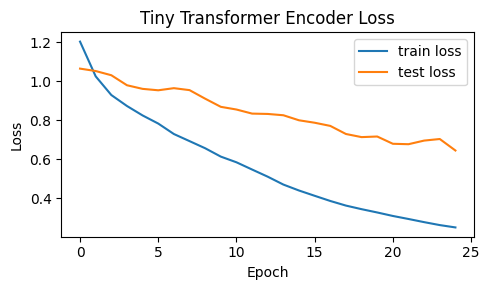

In [48]:
#@title Python Code - Introductory Transformer Encoder

# Tiny transformer encoder for engineering text.
# This example shows attention and context.
# It uses a very small dataset.

# Install TensorFlow if needed.
# !pip install tensorflow==2.20.0

# Reduce TensorFlow warnings for beginners.
import os, warnings, random
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

warnings.filterwarnings('ignore')
import numpy as np

# Import plotting and TensorFlow tools.
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras

tf.get_logger().setLevel('ERROR')
np.random.seed(7)
random.seed(7)

tf.random.set_seed(7)

# Report framework version briefly.
print('TensorFlow version:', tf.__version__)
print('GPU available:', bool(tf.config.list_physical_devices('GPU')))

# Create tiny civil engineering text data.
texts = [
    'bridge corrosion risk high',

    'steel beam corrosion detected',
    'rust on girder needs repair',
    'concrete surface crack observed',

    'deck crack width increasing',
    'wall has visible cracking',
    'drain blocked water ponding',

    'poor drainage near pavement edge',
    'culvert drainage issue reported',
    'corrosion around bearing plate',

    'surface damage on concrete slab',
    'standing water from blocked drain']

# Define simple class labels.
labels_text = [
    'corrosion', 'corrosion', 'corrosion',

    'surface', 'surface', 'surface',
    'drainage', 'drainage', 'drainage',
    'corrosion', 'surface', 'drainage']

# Map labels to integers.
label_to_id = {'corrosion': 0, 'surface': 1, 'drainage': 2}
labels = []

for item in labels_text:
    labels.append(label_to_id[item])

# Convert labels to arrays.
texts = np.array(texts)
labels = np.array(labels, dtype='int32')

# Split data into train and test.
train_texts = texts[:9]
train_labels = labels[:9]

test_texts = texts[9:]
test_labels = labels[9:]

# Build a simple text vectorizer.
max_tokens = 100
seq_len = 6

vectorizer = keras.layers.TextVectorization(
    max_tokens=max_tokens,
    output_mode='int',

    output_sequence_length=seq_len)
vectorizer.adapt(train_texts)

# Check one tokenized example.
sample_tokens = vectorizer(np.array(['bridge corrosion risk high']))
if sample_tokens.shape[1] != seq_len:

    raise ValueError('Unexpected token sequence length.')

# Create a custom transformer block.
class TransformerBlock(keras.layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim):

        super().__init__()
        self.att = keras.layers.MultiHeadAttention(
            num_heads=num_heads,

            key_dim=embed_dim)
        self.ffn = keras.Sequential([
            keras.layers.Dense(ff_dim, activation='relu'),

            keras.layers.Dense(embed_dim)])
        self.norm1 = keras.layers.LayerNormalization()
        self.norm2 = keras.layers.LayerNormalization()

    def call(self, inputs):
        attn_output = self.att(inputs, inputs)
        out1 = self.norm1(inputs + attn_output)

        ffn_output = self.ffn(out1)
        return self.norm2(out1 + ffn_output)

# Create token and position embeddings.
class TokenAndPositionEmbedding(keras.layers.Layer):
    def __init__(self, maxlen, vocab_size, embed_dim):

        super().__init__()
        self.token_emb = keras.layers.Embedding(vocab_size, embed_dim)
        self.pos_emb = keras.layers.Embedding(maxlen, embed_dim)

        self.maxlen = maxlen

    def call(self, x):
        positions = tf.range(start=0, limit=self.maxlen, delta=1)
        positions = self.pos_emb(positions)

        x = self.token_emb(x)
        return x + positions

# Set tiny model dimensions.
embed_dim = 16
num_heads = 2

ff_dim = 32
num_classes = 3

# Build the transformer style classifier.
inputs = keras.Input(shape=(1,), dtype=tf.string)
x = vectorizer(inputs)

x = TokenAndPositionEmbedding(seq_len, max_tokens, embed_dim)(x)
x = TransformerBlock(embed_dim, num_heads, ff_dim)(x)

# Pool sequence information for classification.
x = keras.layers.GlobalAveragePooling1D()(x)
x = keras.layers.Dense(16, activation='relu')(x)

outputs = keras.layers.Dense(num_classes, activation='softmax')(x)
model = keras.Model(inputs=inputs, outputs=outputs)

# Compile the small model.
model.compile(
    optimizer='adam',

    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])

# Show a compact model summary.
model.summary(print_fn=print)

# Train quietly for a few epochs.
history = model.fit(
    tf.constant(train_texts),

    train_labels,
    epochs=25,
    batch_size=3,

    validation_data=(tf.constant(test_texts), test_labels),
    verbose=0)

# Evaluate on the tiny test set.
results = model.evaluate(tf.constant(test_texts), test_labels, verbose=0)
print('Test loss:', round(float(results[0]), 3))

print('Test accuracy:', round(float(results[1]), 3))

# Predict classes for new notes.
new_notes = np.array([
    'bearing corrosion and rust',

    'crack on concrete deck',
    'blocked drain causes ponding'])
preds = model.predict(tf.constant(new_notes), verbose=0)

pred_ids = np.argmax(preds, axis=1)

# Convert predicted ids to names.
id_to_label = {0: 'corrosion', 1: 'surface', 2: 'drainage'}
for i in range(len(new_notes)):

    print(new_notes[i], '->', id_to_label[int(pred_ids[i])])

# Plot training and validation loss.
plt.figure(figsize=(5, 3))
plt.plot(history.history['loss'], label='train loss')

plt.plot(history.history['val_loss'], label='test loss')
plt.title('Tiny Transformer Encoder Loss')
plt.xlabel('Epoch')

plt.ylabel('Loss')
plt.legend()
plt.tight_layout()

plt.show()

## **3. Simple Multimodal Models**

### **3.1. Image Text Fusion**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_11/Lecture_B/image_03_01.jpg?v=1776824500" width="250">



>* Separate encoders create image and text features.
>* Fusion improves predictions using both inputs.

>* Fusion links visual details with text context.
>* Preprocess both inputs for reliable training.

>* Good paired data makes fusion reliable.
>* Fusion combines visuals with meaningful context.



TensorFlow version: 2.21.0
Example pair 1: this is a frog label 6
Example pair 2: this is a truck label 9
Train image shape: (3000, 32, 32, 3)


Model built with image and text branches.
Total parameters: 8586
Test accuracy: 0.84


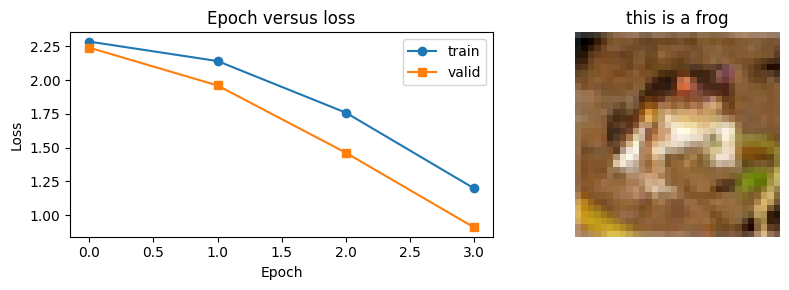

In [49]:
#@title Python Code - Image Text Fusion

# Simple multimodal fusion joins images and text.
# This example uses small CIFAR ten subsets.
# It shows beginner friendly TensorFlow fusion.

# Import quiet libraries for Colab use.
import os, warnings, random
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

warnings.filterwarnings('ignore')
import numpy as np

# Import plotting and TensorFlow tools.
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras

tf.get_logger().setLevel('ERROR')
np.random.seed(7)
tf.random.set_seed(7)

random.seed(7)

# Report TensorFlow version briefly.
print('TensorFlow version:', tf.__version__)

# Load CIFAR ten image data.
(x_train, y_train), (x_test, y_test) = (
    tf.keras.datasets.cifar10.load_data())

class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck']

# Build short text descriptions.
train_labels = y_train.reshape(-1)
test_labels = y_test.reshape(-1)

train_texts = []
test_texts = []

# Create paired text for training.
for label in train_labels:
    train_texts.append('this is a ' + class_names[int(label)])

for label in test_labels:
    test_texts.append('this is a ' + class_names[int(label)])

# Keep only small subsets.
train_size = 3000
test_size = 600

x_train = x_train[:train_size].astype('float32') / 255.0
y_train = train_labels[:train_size]
x_test = x_test[:test_size].astype('float32') / 255.0

y_test = test_labels[:test_size]

# Slice matching text subsets.
train_texts = train_texts[:train_size]
test_texts = test_texts[:test_size]

# Convert text to TensorFlow string tensors.
train_texts_tf = tf.convert_to_tensor(train_texts, dtype=tf.string)
test_texts_tf = tf.convert_to_tensor(test_texts, dtype=tf.string)

num_classes = 10

# Show a few paired examples.
print('Example pair 1:', train_texts[0], 'label', int(y_train[0]))
print('Example pair 2:', train_texts[1], 'label', int(y_train[1]))

print('Train image shape:', x_train.shape)

# Prepare a simple text vectorizer.
vectorizer = keras.layers.TextVectorization(
    max_tokens=50,

    output_mode='int',
    output_sequence_length=5)

text_ds = tf.data.Dataset.from_tensor_slices(train_texts_tf).batch(64)
vectorizer.adapt(text_ds)

# Convert labels to one hot.
y_train_cat = keras.utils.to_categorical(y_train, num_classes)
y_test_cat = keras.utils.to_categorical(y_test, num_classes)

# Build the image branch.
image_input = keras.Input(shape=(32, 32, 3), name='image')
x1 = keras.layers.Conv2D(16, 3, activation='relu')(image_input)

x1 = keras.layers.MaxPooling2D()(x1)
x1 = keras.layers.Conv2D(32, 3, activation='relu')(x1)

# Finish image features compactly.
x1 = keras.layers.GlobalAveragePooling2D()(x1)
x1 = keras.layers.Dense(32, activation='relu')(x1)

# Build the text branch.
text_input = keras.Input(shape=(), dtype=tf.string, name='text')
x2 = vectorizer(text_input)

x2 = keras.layers.Embedding(50, 8)(x2)
x2 = keras.layers.GlobalAveragePooling1D()(x2)

# Finish text features compactly.
x2 = keras.layers.Dense(16, activation='relu')(x2)

# Fuse image and text features.
fused = keras.layers.Concatenate()([x1, x2])
fused = keras.layers.Dense(32, activation='relu')(fused)

output = keras.layers.Dense(num_classes, activation='softmax')(fused)
model = keras.Model(inputs=[image_input, text_input], outputs=output)

# Compile the small multimodal model.
model.compile(
    optimizer='adam',

    loss='categorical_crossentropy',
    metrics=['accuracy'])

# Print a compact model summary.
model.summary(print_fn=lambda line: None)
print('Model built with image and text branches.')

print('Total parameters:', model.count_params())

# Train quietly for a few epochs.
history = model.fit(
    {'image': x_train, 'text': train_texts_tf},

    y_train_cat,
    validation_data=(
        {'image': x_test, 'text': test_texts_tf},

        y_test_cat),
    epochs=4,
    batch_size=64,

    verbose=0)

# Evaluate the trained model.
results = model.evaluate(
    {'image': x_test, 'text': test_texts_tf},

    y_test_cat,
    verbose=0)
print('Test accuracy:', round(float(results[1]), 3))

# Plot losses and one sample pair.
fig, axes = plt.subplots(1, 2, figsize=(9, 3))
axes[0].plot(history.history['loss'], marker='o', label='train')

axes[0].plot(history.history['val_loss'], marker='s', label='valid')
axes[0].set_title('Epoch versus loss')
axes[0].set_xlabel('Epoch')

axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].imshow(x_train[0])
axes[1].set_title(train_texts[0])
axes[1].axis('off')

plt.tight_layout()
plt.show()

### **3.2. Image Text Fusion**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_11/Lecture_B/image_03_02.jpg?v=1776824540" width="250">



>* Fusion combines image and text features.
>* Together they improve engineering interpretation.

>* Image and text features merge together.
>* Fusion reduces ambiguity through shared context.

>* Align data and keep fusion simple.
>* Images and text can offset weaknesses.



TensorFlow version: 2.21.0
Running on: CPU
Example text: civil inspection image showing frog features
Test accuracy: 0.958
Top left confusion block:
[[129   0   0   0   0]
 [  0 152   0   0   0]
 [  0   0 146   0   0]
 [  0   0   0 151   0]
 [  0   0   0   0 136]]


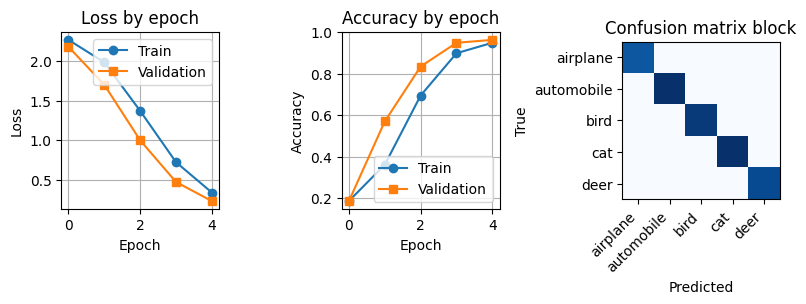

In [50]:
#@title Python Code - Image Text Fusion

# Simple fusion joins images and short text.
# This example uses CIFAR ten data.
# Small models help beginners learn safely.

# Install helper library if needed.
# !pip install -q scikit-learn

# Reduce warnings for cleaner notebook output.
import os, warnings, random
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

warnings.filterwarnings('ignore')
random.seed(7)

# Import core learning libraries.
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from sklearn.metrics import confusion_matrix

tf.get_logger().setLevel('ERROR')
np.random.seed(7)
tf.random.set_seed(7)

print('TensorFlow version:', tf.__version__)

# Check whether a GPU is available.
gpu_name = 'GPU' if tf.config.list_physical_devices('GPU') else 'CPU'
print('Running on:', gpu_name)

# Load CIFAR ten image data.
(train_images, train_labels), (test_images, test_labels) = (
    tf.keras.datasets.cifar10.load_data())

train_labels = train_labels.reshape(-1)
test_labels = test_labels.reshape(-1)

# Keep only small subsets for speed.
train_count = 6000
test_count = 1500

train_images = train_images[:train_count].astype('float32') / 255.0
train_labels = train_labels[:train_count]

test_images = test_images[:test_count].astype('float32') / 255.0
test_labels = test_labels[:test_count]

# Define CIFAR ten class names.
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',

    'dog', 'frog', 'horse', 'ship', 'truck']

# Build simple engineering themed text descriptions.
text_templates = [
    'civil inspection image showing {} features',

    'site note describing {} condition today',
    'engineer report mentions {} in scene',
    'field photo with {} related context']

# Create one short text for each label.
def build_texts(labels):
    texts = []

    for i in range(len(labels)):
        name = class_names[int(labels[i])]
        template = text_templates[i % len(text_templates)]

        texts.append(template.format(name))
    return texts

# Generate paired text for images.
train_texts = build_texts(train_labels)
test_texts = build_texts(test_labels)

# Show one paired example.
print('Example text:', train_texts[0])

# Prepare a simple text vectorizer.
max_tokens = 1000
seq_len = 12

vectorizer = tf.keras.layers.TextVectorization(
    max_tokens=max_tokens,
    output_mode='int',

    output_sequence_length=seq_len)
vectorizer.adapt(np.array(train_texts))

# Convert text into integer sequences.
train_text_ids = vectorizer(np.array(train_texts)).numpy()
test_text_ids = vectorizer(np.array(test_texts)).numpy()

# Validate paired data shapes.
assert len(train_images) == len(train_text_ids)
assert len(test_images) == len(test_text_ids)

assert train_images.shape[1:] == (32, 32, 3)

# Build the image branch.
image_input = tf.keras.Input(shape=(32, 32, 3), name='image')
x1 = tf.keras.layers.Conv2D(16, 3, activation='relu')(image_input)

x1 = tf.keras.layers.MaxPooling2D()(x1)
x1 = tf.keras.layers.Conv2D(32, 3, activation='relu')(x1)

# Continue the image branch.
x1 = tf.keras.layers.MaxPooling2D()(x1)
x1 = tf.keras.layers.GlobalAveragePooling2D()(x1)

x1 = tf.keras.layers.Dense(32, activation='relu')(x1)

# Build the text branch.
text_input = tf.keras.Input(shape=(seq_len,), name='text')
x2 = tf.keras.layers.Embedding(max_tokens, 16)(text_input)

x2 = tf.keras.layers.GlobalAveragePooling1D()(x2)
x2 = tf.keras.layers.Dense(16, activation='relu')(x2)

# Fuse image and text features.
fused = tf.keras.layers.Concatenate()([x1, x2])
fused = tf.keras.layers.Dense(32, activation='relu')(fused)

output = tf.keras.layers.Dense(10, activation='softmax')(fused)

# Create and compile the model.
model = tf.keras.Model(inputs=[image_input, text_input], outputs=output)
model.compile(

    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])

# Train quietly for a few epochs.
history = model.fit(
    {'image': train_images, 'text': train_text_ids},

    train_labels,
    validation_split=0.2,
    epochs=5,

    batch_size=64,
    verbose=0)

# Evaluate on the test subset.
test_loss, test_acc = model.evaluate(
    {'image': test_images, 'text': test_text_ids},

    test_labels,
    verbose=0)
print('Test accuracy:', round(float(test_acc), 3))

# Predict classes for the confusion matrix.
pred_probs = model.predict(
    {'image': test_images, 'text': test_text_ids},

    verbose=0)
pred_labels = np.argmax(pred_probs, axis=1)

# Build a compact confusion matrix.
cm = confusion_matrix(test_labels, pred_labels)
cm_small = cm[:5, :5]

print('Top left confusion block:')
print(cm_small)

# Create one figure with three panels.
fig, axes = plt.subplots(1, 3, figsize=(8, 3))
axes[0].plot(history.history['loss'], marker='o')

axes[0].plot(history.history['val_loss'], marker='s')
axes[0].set_title('Loss by epoch')
axes[0].set_xlabel('Epoch')

# Finish the loss panel.
axes[0].set_ylabel('Loss')
axes[0].legend(['Train', 'Validation'])

axes[0].grid(True)

# Plot accuracy curves.
axes[1].plot(history.history['accuracy'], marker='o')
axes[1].plot(history.history['val_accuracy'], marker='s')

axes[1].set_title('Accuracy by epoch')
axes[1].set_xlabel('Epoch')

# Finish the accuracy panel.
axes[1].set_ylabel('Accuracy')
axes[1].legend(['Train', 'Validation'])

axes[1].grid(True)

# Plot a small confusion matrix block.
image_plot = axes[2].imshow(cm_small, cmap='Blues')
axes[2].set_title('Confusion matrix block')

axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('True')

# Add labels and layout.
axes[2].set_xticks(range(5))
axes[2].set_yticks(range(5))

axes[2].set_xticklabels(class_names[:5], rotation=45, ha='right')
axes[2].set_yticklabels(class_names[:5])

# Show the final teaching figure.
plt.tight_layout()
plt.show()

### **3.3. Model Output Review**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_11/Lecture_B/image_03_03.jpg?v=1776824581" width="250">



>* Review outputs using both image and text.
>* Check fusion is coherent, reliable, and useful.

>* Compare correct, wrong, and uncertain outputs.
>* Check balanced fusion and realistic reliability.

>* Review outputs for trust and practical use.
>* Check bias, plausibility, and input balance.



TensorFlow version: 2.21.0
GPU available: False
Class: airplane
Matched score: 0.507
Mismatched score: 0.505
Class: automobile
Matched score: 0.505
Mismatched score: 0.507
Class: ship
Matched score: 0.508
Mismatched score: 0.507


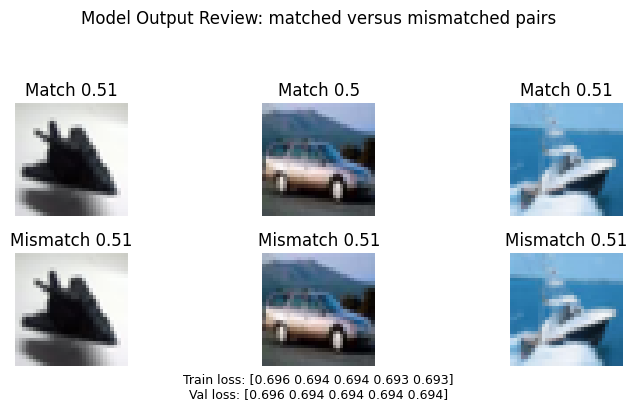

In [51]:
#@title Python Code - Model Output Review

# This lesson reviews simple multimodal model outputs.
# We compare matching and mismatching image text pairs.
# Civil engineering ideas guide the inspection example.

# Import quiet libraries for Colab use.
import os, warnings, random
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

warnings.filterwarnings('ignore')
import numpy as np

# Import plotting and TensorFlow tools.
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras

tf.get_logger().setLevel('ERROR')
np.random.seed(7)
random.seed(7)

tf.random.set_seed(7)

# Report TensorFlow version briefly.
print('TensorFlow version:', tf.__version__)
print('GPU available:', bool(tf.config.list_physical_devices('GPU')))

# Load CIFAR ten image data.
(x_train, y_train), _ = keras.datasets.cifar10.load_data()
y_train = y_train.reshape(-1)

# Keep only three simple classes.
class_ids = [0, 1, 8]
class_names = ['airplane', 'automobile', 'ship']

text_map = {}

# Build short engineering style texts.
text_map[0] = 'site photo shows aircraft near structure'
text_map[1] = 'site photo shows vehicle near roadway'

text_map[8] = 'site photo shows water vessel near bridge'

# Select a small balanced subset.
images_list = []
texts_list = []

labels_list = []
per_class = 180

# Gather examples for each class.
for cid in class_ids:
    idx = np.where(y_train == cid)[0][:per_class]

    images_list.append(x_train[idx])
    labels_list.append(y_train[idx])
    texts_list.extend([text_map[cid]] * len(idx))

# Combine selected examples safely.
images = np.concatenate(images_list, axis=0).astype('float32') / 255.0
labels = np.concatenate(labels_list, axis=0)

texts = np.array(texts_list, dtype=object)

# Build binary match targets.
match_targets = np.ones(len(labels), dtype='float32')
wrong_texts = []

# Create mismatched texts by shifting labels.
for value in labels:
    if value == 0:

        wrong_texts.append(text_map[1])
    elif value == 1:
        wrong_texts.append(text_map[8])

    else:
        wrong_texts.append(text_map[0])

wrong_texts = np.array(wrong_texts, dtype=object)

# Stack matched and mismatched pairs.
all_images = np.concatenate([images, images], axis=0)
all_texts = np.concatenate([texts, wrong_texts], axis=0)

all_targets = np.concatenate([match_targets, np.zeros(len(labels), dtype='float32')])

# Shuffle the training pairs.
order = np.arange(len(all_targets))
np.random.shuffle(order)

all_images = all_images[order]
all_texts = all_texts[order]
all_targets = all_targets[order]

# Split into train and validation sets.
split = int(0.8 * len(all_targets))
train_images = all_images[:split]

train_texts = all_texts[:split]
train_targets = all_targets[:split]

val_images = all_images[split:]
val_texts = all_texts[split:]
val_targets = all_targets[split:]

# Convert text arrays to TensorFlow string tensors.
# This avoids Keras data adapter issues with NumPy unicode dtypes.
train_texts_tf = tf.convert_to_tensor(train_texts, dtype=tf.string)

val_texts_tf = tf.convert_to_tensor(val_texts, dtype=tf.string)

# Vectorize short text descriptions.
vectorizer = keras.layers.TextVectorization(
    max_tokens=50,

    output_mode='int',
    output_sequence_length=8)
vectorizer.adapt(train_texts_tf)

# Build a tiny image branch.
image_input = keras.Input(shape=(32, 32, 3), name='image')
x1 = keras.layers.Conv2D(16, 3, activation='relu')(image_input)

x1 = keras.layers.MaxPooling2D()(x1)
x1 = keras.layers.Conv2D(32, 3, activation='relu')(x1)
x1 = keras.layers.GlobalAveragePooling2D()(x1)

# Build a tiny text branch.
text_input = keras.Input(shape=(), dtype=tf.string, name='text')
x2 = vectorizer(text_input)

x2 = keras.layers.Embedding(50, 8)(x2)
x2 = keras.layers.GlobalAveragePooling1D()(x2)

# Fuse image and text features.
joined = keras.layers.Concatenate()([x1, x2])
joined = keras.layers.Dense(16, activation='relu')(joined)

output = keras.layers.Dense(1, activation='sigmoid')(joined)

# Compile the multimodal review model.
model = keras.Model(inputs=[image_input, text_input], outputs=output)
model.compile(

    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy'])

# Train quietly for a few epochs.
history = model.fit(
    {'image': train_images, 'text': train_texts_tf},

    train_targets,
    validation_data=(
        {'image': val_images, 'text': val_texts_tf},

        val_targets),
    epochs=5,
    batch_size=32,

    verbose=0)

# Choose one example from each class.
review_ids = []
for cid in class_ids:

    found = np.where(labels == cid)[0][0]
    review_ids.append(found)

# Prepare matched and mismatched review texts.
review_images = images[review_ids]
review_labels = labels[review_ids]

review_match = tf.convert_to_tensor(texts[review_ids], dtype=tf.string)
review_wrong = tf.convert_to_tensor(wrong_texts[review_ids], dtype=tf.string)

# Predict scores for both pair types.
score_match = model.predict(
    {'image': review_images, 'text': review_match},

    verbose=0
).reshape(-1)

score_wrong = model.predict(
    {'image': review_images, 'text': review_wrong},
    verbose=0

).reshape(-1)

# Print a short output review.
for i in range(len(review_ids)):
    name = class_names[class_ids.index(int(review_labels[i]))]

    print('Class:', name)
    print('Matched score:', round(float(score_match[i]), 3))
    print('Mismatched score:', round(float(score_wrong[i]), 3))

# Create one figure with examples and loss.
fig, axes = plt.subplots(2, 3, figsize=(8, 4))
fig.suptitle('Model Output Review: matched versus mismatched pairs')

# Show matched image text pairs.
for i in range(3):
    axes[0, i].imshow(review_images[i])

    axes[0, i].axis('off')
    title_text = 'Match ' + str(round(float(score_match[i]), 2))
    axes[0, i].set_title(title_text)

    axes[0, i].set_xlabel(texts[review_ids][i], fontsize=8)

# Show mismatched image text pairs.
for i in range(3):
    axes[1, i].imshow(review_images[i])

    title_text = 'Mismatch ' + str(round(float(score_wrong[i]), 2))
    axes[1, i].set_title(title_text)
    axes[1, i].set_xlabel(wrong_texts[review_ids][i], fontsize=8)

    axes[1, i].axis('off')

# Add epoch loss text inside figure.
losses = history.history['loss']
val_losses = history.history['val_loss']

loss_note = 'Train loss: ' + str(np.round(losses, 3))
loss_note = loss_note + '\nVal loss: ' + str(np.round(val_losses, 3))
fig.text(0.5, 0.01, loss_note, ha='center', fontsize=9)

plt.tight_layout(rect=[0, 0.05, 1, 0.92])
plt.show()

# <font color="#418FDE" size="6.5" uppercase>**NLP, Transformers, and Multi-Modal Models**</font>


In this lecture, you learned to:
- Preprocess simple text data and implement introductory TensorFlow natural language processing workflows. 
- Explain the basic idea of attention and transformers and build small TensorFlow examples that use these mechanisms. 
- Describe and implement a simple multi-modal TensorFlow model that combines image and text information. 

In the next Module (Module 12), we will go over 'Applied Generative AI in Civil Engineering, Part II'